# 02 - Modele Perceptron

## Objectif du notebook

Le Perceptron sert ici de **baseline lineaire minimale**. L'objectif est de mesurer jusqu'ou un classifieur lineaire simple peut aller sur le probleme **Leaf Classification**, puis d'etudier l'effet du preprocessing et du tuning sur ses performances.


## Rappel theorique

- Le Perceptron est un classifieur lineaire.
- Il est appris par une logique de mise a jour basee sur les erreurs de classification.
- Il ne suppose pas que les donnees suivent une loi gaussienne.
- Il est utile pour tester si le probleme est approximativement lineairement separable.


## Lien avec l'EDA et hypotheses

L'EDA a montre plusieurs points importants :

- les variables n'evoluent pas sur les memes echelles ;
- le dataset est equilibre entre les 99 especes ;
- les variables presentent une forte redondance ;
- la structure globale du probleme semble au moins partiellement non lineaire.

Hypotheses de travail pour ce notebook :

1. La version **default** devrait fournir une baseline correcte, mais limitee.
2. La version **preprocessed** devrait beneficier du `StandardScaler` et potentiellement de la PCA.
3. La version **tuned** peut encore gagner un peu, mais ne devrait pas transformer radicalement un modele lineaire en meilleur modele global.


## Protocole experimental

- validation croisee : `StratifiedKFold`
- metrique principale : `f1_macro`
- metrique secondaire : `accuracy`
- comparaison entre trois variantes : `default`, `preprocessed`, `tuned`
- le preprocessing est place dans un pipeline pour eviter toute fuite de donnees


In [15]:
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import GridSearchCV, StratifiedKFold

sys.path.insert(0, str(Path("..").resolve()))

from src.donnees import charger_donnees
from src.evaluation import evaluer_modele_cv, extraire_top_confusions, predictions_oof
from src.modeles import creer_modele_simple, initialiser_grille_tuning, obtenir_definition_modele
from src.pipelines import creer_pipeline_ameliore
from src.resultats import (
    sauvegarder_mesures,
    sauvegarder_predictions,
    sauvegarder_resultats_grid_search,
)
from src.visualisation import (
    tracer_comparaison_variantes,
    tracer_heatmap_tuning,
    tracer_top_confusions,
)

sns.set_theme(style="whitegrid")
%matplotlib inline


In [16]:
MODEL_NAME = "perceptron"
USE_PCA = True
CV_TUNING = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

definition = obtenir_definition_modele(MODEL_NAME)
X, y, label_encoder = charger_donnees()

print(definition["nom_affiche"])
print(definition["description"])
print(definition["hypothese"])
print(f"Dimensions de X : {X.shape}")
print(f"Nombre de classes : {len(label_encoder.classes_)}")


Perceptron
Modele lineaire simple servant de baseline rapide.
Le Perceptron donne une baseline correcte mais limitera la separabilite non lineaire.
Dimensions de X : (990, 192)
Nombre de classes : 99


## Strategie de preprocessing

Pour le Perceptron, le `StandardScaler` est justifie par l'EDA, qui a montre des ordres de grandeur tres differents entre les familles de variables. La PCA est testee comme variante car l'EDA a egalement revele de la redondance entre variables. Tout le preprocessing est integre dans le pipeline pour eviter le data leakage.


## 1. Variante default

### Hypothese

Cette premiere version correspond au Perceptron brut, sans scaling ni PCA. On s'attend a une baseline utile pour situer le probleme, mais probablement sous-optimale compte tenu des differences d'echelle observees dans l'EDA.


In [17]:
modele_default = creer_modele_simple(MODEL_NAME)
mesures_default = evaluer_modele_cv(modele_default, X, y)
mesures_default["generalization_gap_accuracy"] = mesures_default["train_accuracy_mean"] - mesures_default["val_accuracy_mean"]
mesures_default["generalization_gap_f1_macro"] = mesures_default["train_f1_macro_mean"] - mesures_default["val_f1_macro_mean"]
chemin_default = sauvegarder_mesures(MODEL_NAME, "default", mesures_default)

tableau_default = pd.DataFrame([mesures_default], index=["default"])
display(tableau_default[[
    "val_accuracy_mean",
    "val_accuracy_std",
    "val_f1_macro_mean",
    "val_f1_macro_std",
    "train_accuracy_mean",
    "train_f1_macro_mean",
    "generalization_gap_accuracy",
    "generalization_gap_f1_macro",
    "elapsed_seconds",
]])
print(f"Mesures sauvegardees dans : {chemin_default}")


,val_accuracy_mean,val_accuracy_std,val_f1_macro_mean,val_f1_macro_std,train_accuracy_mean,train_f1_macro_mean,generalization_gap_accuracy,generalization_gap_f1_macro,elapsed_seconds
default,0.811111,0.027217,0.76995,0.036134,0.887374,0.850522,0.076263,0.080572,0.848069


Mesures sauvegardees dans : C:\Users\moulo\Documents\Projet_Session_IFT712\results\metrics\perceptron__default.json


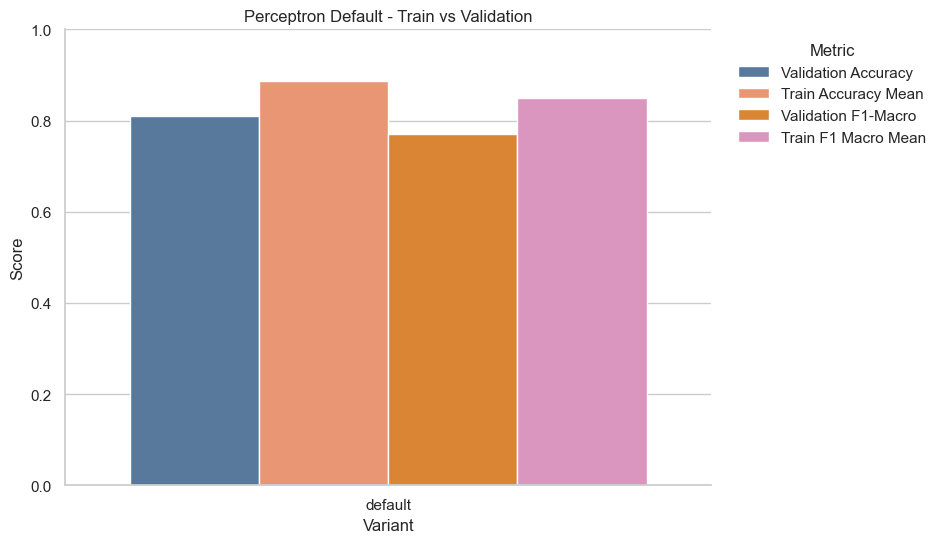

In [18]:
profil_default = pd.DataFrame([
    {
        "variante": "default",
        **mesures_default,
    }
])

tracer_comparaison_variantes(
    profil_default,
    colonnes_metriques=["val_accuracy_mean", "train_accuracy_mean", "val_f1_macro_mean", "train_f1_macro_mean"],
    titre="Perceptron Default - Train vs Validation",
)
plt.show()


In [19]:
predictions_default = predictions_oof(modele_default, X, y, label_encoder=label_encoder)
chemin_predictions_default = sauvegarder_predictions(MODEL_NAME, "default", predictions_default)
confusions_default = extraire_top_confusions(
    predictions_default["y_true"].to_numpy(),
    predictions_default["y_pred"].to_numpy(),
    label_encoder=label_encoder,
    top_n=10,
)

print(f"Predictions OOF sauvegardees dans : {chemin_predictions_default}")
display(confusions_default)


Predictions OOF sauvegardees dans : C:\Users\moulo\Documents\Projet_Session_IFT712\results\predictions\perceptron__default__predictions.csv


,classe_vraie,classe_predite,nombre_erreurs
0,Betula_Pendula,Quercus_Coccifera,3
1,Fagus_Sylvatica,Cotinus_Coggygria,3
2,Magnolia_Salicifolia,Cotinus_Coggygria,3
3,Magnolia_Salicifolia,Ilex_Aquifolium,3
4,Populus_Nigra,Populus_Grandidentata,3
5,Acer_Mono,Acer_Pictum,2
6,Acer_Rubrum,Betula_Pendula,2
7,Cornus_Macrophylla,Phildelphus,2
8,Crataegus_Monogyna,Acer_Rubrum,2
9,Cytisus_Battandieri,Quercus_Ilex,2


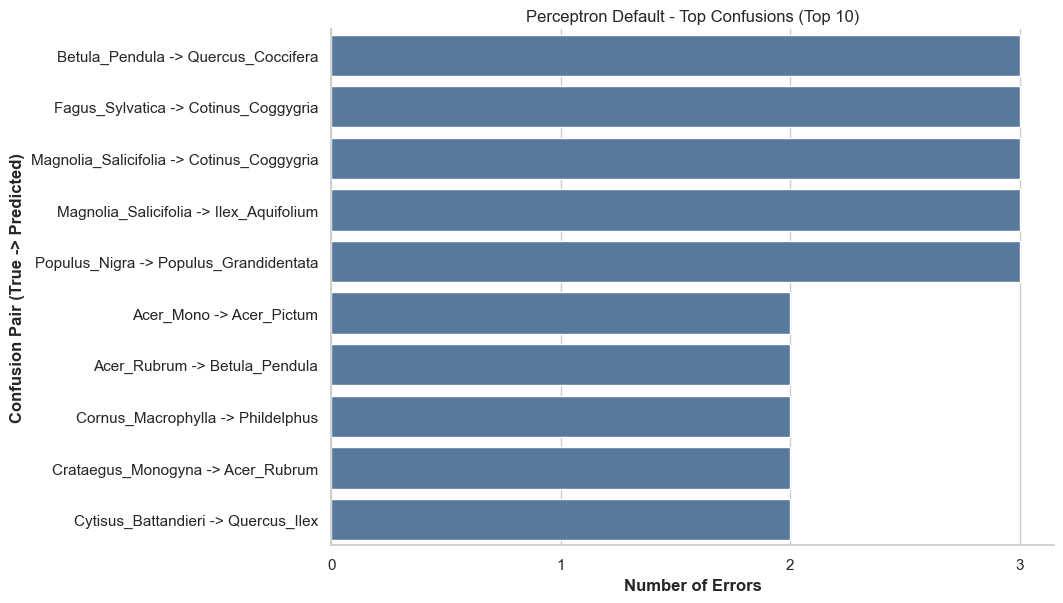

In [20]:
tracer_top_confusions(confusions_default, titre="Perceptron Default - Top Confusions")
plt.show()


### Deductions apres la variante default

La variante default fournit une baseline lineaire correcte, mais clairement limitee : l'`accuracy` moyenne atteint environ **0.811** et le `F1-macro` moyen environ **0.770**. Pour un modele aussi simple, ce niveau de performance montre que les donnees contiennent deja une structure exploitable, mais qu'une frontiere lineaire brute ne suffit pas a bien separer l'ensemble des 99 especes.

Le lien avec l'EDA est direct. L'EDA avait montre de fortes differences d'echelle entre `margin`, `shape` et `texture`. Le fait que le Perceptron brut reste nettement en retrait confirme que ces ecarts d'echelle perturbent fortement un modele appris par mises a jour iteratives. Les top confusions du modele default montrent aussi plusieurs paires d'especes confondues **3 fois**, ce qui reste coherent avec l'idee deja sugguree par l'EDA : le probleme n'est pas parfaitement lineairement separable et certaines especes restent proches dans l'espace descripteur.

Du point de vue de la generalisation, le graphique train vs validation montre un **ecart modere** entre apprentissage et validation, avec un `generalization gap` d'environ **0.076** en accuracy et **0.081** en `F1-macro`. On n'est donc pas dans un overfitting extreme, mais plutot dans une situation de **sous-performance structurelle** : le modele apprend quelque chose, sans pour autant disposer d'une capacite suffisante pour bien capturer toute la complexite du probleme.


## 2. Variante preprocessed

### Hypothese

Cette seconde version applique un `StandardScaler`, puis une PCA fixe. Si l'EDA a correctement identifie les besoins du modele, on devrait observer un gain de stabilite et de performance par rapport a la version default.


In [21]:
modele_preprocessed = creer_pipeline_ameliore(MODEL_NAME, utiliser_pca=USE_PCA)
mesures_preprocessed = evaluer_modele_cv(modele_preprocessed, X, y)
mesures_preprocessed["generalization_gap_accuracy"] = mesures_preprocessed["train_accuracy_mean"] - mesures_preprocessed["val_accuracy_mean"]
mesures_preprocessed["generalization_gap_f1_macro"] = mesures_preprocessed["train_f1_macro_mean"] - mesures_preprocessed["val_f1_macro_mean"]
mesures_preprocessed["utilise_pca"] = USE_PCA
chemin_preprocessed = sauvegarder_mesures(MODEL_NAME, "preprocessed", mesures_preprocessed)

tableau_preprocessed = pd.DataFrame([mesures_preprocessed], index=["preprocessed"])
display(tableau_preprocessed[[
    "val_accuracy_mean",
    "val_accuracy_std",
    "val_f1_macro_mean",
    "val_f1_macro_std",
    "train_accuracy_mean",
    "train_f1_macro_mean",
    "generalization_gap_accuracy",
    "generalization_gap_f1_macro",
    "elapsed_seconds",
]])
print(f"Mesures sauvegardees dans : {chemin_preprocessed}")


,val_accuracy_mean,val_accuracy_std,val_f1_macro_mean,val_f1_macro_std,train_accuracy_mean,train_f1_macro_mean,generalization_gap_accuracy,generalization_gap_f1_macro,elapsed_seconds
preprocessed,0.9,0.024618,0.890447,0.030592,0.998485,0.998531,0.098485,0.108084,2.240991


Mesures sauvegardees dans : C:\Users\moulo\Documents\Projet_Session_IFT712\results\metrics\perceptron__preprocessed.json


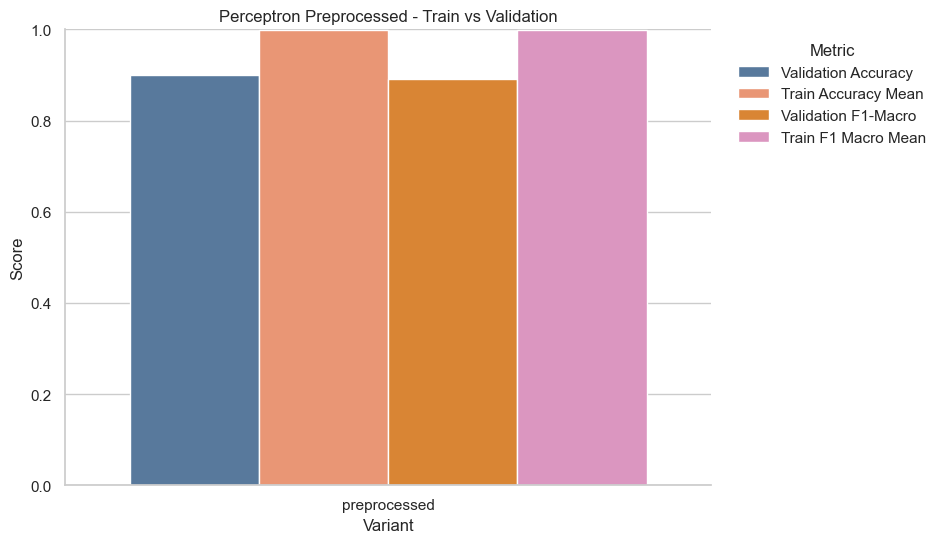

In [22]:
profil_preprocessed = pd.DataFrame([
    {
        "variante": "preprocessed",
        **mesures_preprocessed,
    }
])

tracer_comparaison_variantes(
    profil_preprocessed,
    colonnes_metriques=["val_accuracy_mean", "train_accuracy_mean", "val_f1_macro_mean", "train_f1_macro_mean"],
    titre="Perceptron Preprocessed - Train vs Validation",
)
plt.show()


,variante,val_accuracy_mean,val_f1_macro_mean,elapsed_seconds
0,default,0.811111,0.769950,0.848069
1,preprocessed,0.900000,0.890447,2.240991


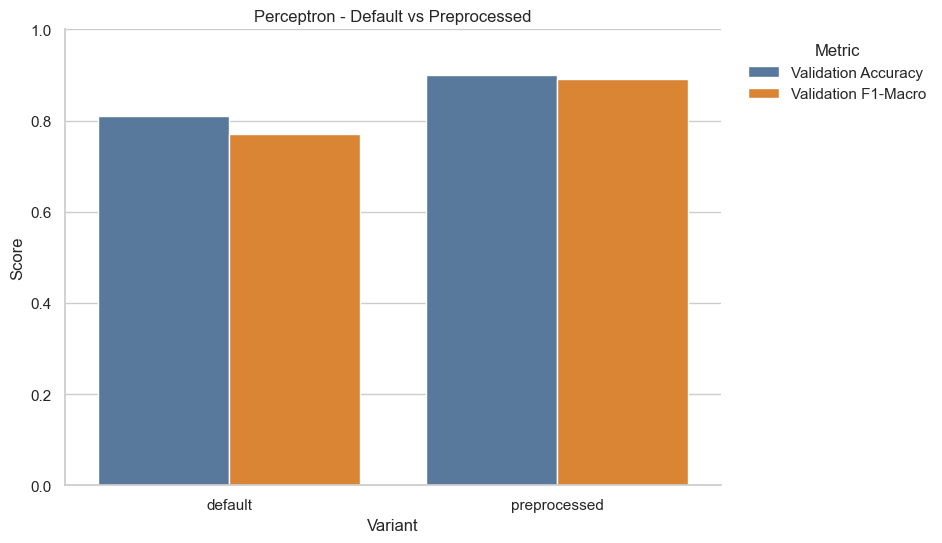

In [23]:
comparaison_default_preprocessed = pd.DataFrame([
    {"variante": "default", **mesures_default},
    {"variante": "preprocessed", **mesures_preprocessed},
])

display(comparaison_default_preprocessed[[
    "variante",
    "val_accuracy_mean",
    "val_f1_macro_mean",
    "elapsed_seconds",
]])

tracer_comparaison_variantes(
    comparaison_default_preprocessed,
    colonnes_metriques=["val_accuracy_mean", "val_f1_macro_mean"],
    titre="Perceptron - Default vs Preprocessed",
)
plt.show()


Predictions OOF sauvegardees dans : C:\Users\moulo\Documents\Projet_Session_IFT712\results\predictions\perceptron__preprocessed__predictions.csv


,classe_vraie,classe_predite,nombre_erreurs
0,Ilex_Cornuta,Quercus_Castaneifolia,2
1,Quercus_Coccifera,Quercus_Texana,2
2,Quercus_x_Hispanica,Quercus_Phillyraeoides,2
3,Acer_Capillipes,Tilia_Tomentosa,1
4,Acer_Mono,Acer_Circinatum,1
5,Acer_Opalus,Tilia_Tomentosa,1
6,Acer_Pictum,Lithocarpus_Edulis,1
7,Acer_Rufinerve,Alnus_Viridis,1
8,Acer_Rufinerve,Tilia_Tomentosa,1
9,Acer_Saccharinum,Viburnum_x_Rhytidophylloides,1


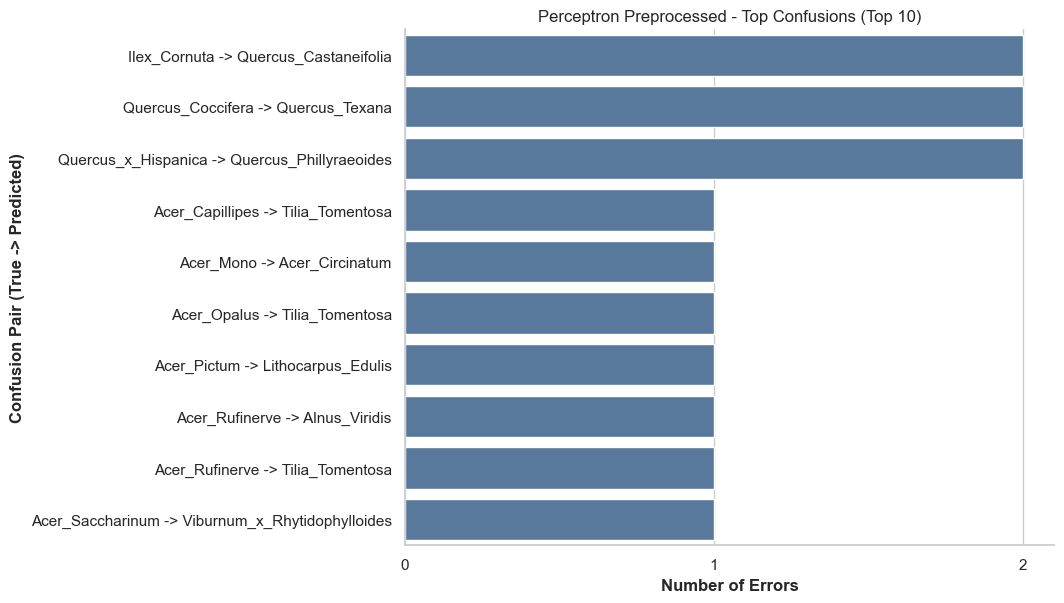

In [24]:
predictions_preprocessed = predictions_oof(modele_preprocessed, X, y, label_encoder=label_encoder)
chemin_predictions_preprocessed = sauvegarder_predictions(MODEL_NAME, "preprocessed", predictions_preprocessed)
confusions_preprocessed = extraire_top_confusions(
    predictions_preprocessed["y_true"].to_numpy(),
    predictions_preprocessed["y_pred"].to_numpy(),
    label_encoder=label_encoder,
    top_n=10,
)

print(f"Predictions OOF sauvegardees dans : {chemin_predictions_preprocessed}")
display(confusions_preprocessed)

tracer_top_confusions(confusions_preprocessed, titre="Perceptron Preprocessed - Top Confusions")
plt.show()


### Deductions apres la variante preprocessed

Le preprocessing apporte ici un **gain net et majeur**. L'`accuracy` moyenne passe d'environ **0.811** a **0.900**, tandis que le `F1-macro` moyen passe d'environ **0.770** a **0.890**. Il ne s'agit donc pas d'un simple ajustement marginal : c'est le principal saut de performance du notebook.

Ce resultat confirme tres fortement les conclusions de l'EDA. Comme l'EDA avait mis en evidence des variables sur des ordres de grandeur differents, l'ajout du `StandardScaler` et de la PCA etait scientifiquement justifie. Le graphe des confusions montre egalement une amelioration qualitative : les pires confusions tombent a **2 erreurs** au lieu de **3** pour la variante default. En revanche, le score ne devient pas parfait, malgre un score d'apprentissage tres eleve. Cela suggere que, meme avec un bon preprocessing, le Perceptron atteint deja une limite liee a sa nature lineaire, ce qui reste coherent avec les indices de non-linearite observes dans l'EDA.

Le diagnostic train vs validation rend cette lecture encore plus claire. Les scores d'apprentissage montent presque a **1.00**, alors que la validation reste autour de **0.90**. Le `generalization gap` devient alors nettement plus large, autour de **0.098** en accuracy et **0.108** en `F1-macro`. On est donc moins dans l'underfitting que dans un **debut d'overfitting controle** : le preprocessing permet au modele de mieux exploiter les donnees, mais il ne supprime pas les limites de generalisation d'un classifieur lineaire sur un probleme probablement plus complexe.


## 3. Variante tuned

### Hypothese

On tune maintenant le meilleur cadre logique pour ce modele, a savoir le pipeline preprocessse. On s'attend a une amelioration moderee, principalement liee a la regularisation, mais pas a un changement de nature du modele.

### Grille de recherche

Les hyperparametres explores sont ceux prepares dans le registre central : `alpha` et `penalty`.


In [25]:
grille_tuning = initialiser_grille_tuning(MODEL_NAME)
display(pd.Series(grille_tuning, name="valeurs_testees"))

debut_tuning = time.perf_counter()
grid = GridSearchCV(
    estimator=creer_pipeline_ameliore(MODEL_NAME, utiliser_pca=USE_PCA),
    param_grid=grille_tuning,
    scoring={"accuracy": "accuracy", "f1_macro": "f1_macro"},
    refit="f1_macro",
    cv=CV_TUNING,
    n_jobs=1,
    return_train_score=True,
)
grid.fit(X, y)
temps_tuning = time.perf_counter() - debut_tuning

resultats_grid = pd.DataFrame(grid.cv_results_)
chemin_grid = sauvegarder_resultats_grid_search(MODEL_NAME, resultats_grid)

best_index = grid.best_index_
mesures_tuned = {
    "val_accuracy_mean": float(resultats_grid.loc[best_index, "mean_test_accuracy"]),
    "val_accuracy_std": float(resultats_grid.loc[best_index, "std_test_accuracy"]),
    "val_f1_macro_mean": float(resultats_grid.loc[best_index, "mean_test_f1_macro"]),
    "val_f1_macro_std": float(resultats_grid.loc[best_index, "std_test_f1_macro"]),
    "train_accuracy_mean": float(resultats_grid.loc[best_index, "mean_train_accuracy"]),
    "train_f1_macro_mean": float(resultats_grid.loc[best_index, "mean_train_f1_macro"]),
    "generalization_gap_accuracy": float(resultats_grid.loc[best_index, "mean_train_accuracy"] - resultats_grid.loc[best_index, "mean_test_accuracy"]),
    "generalization_gap_f1_macro": float(resultats_grid.loc[best_index, "mean_train_f1_macro"] - resultats_grid.loc[best_index, "mean_test_f1_macro"]),
    "elapsed_seconds": float(temps_tuning),
    "meilleurs_parametres": grid.best_params_,
    "utilise_pca": USE_PCA,
}
chemin_tuned = sauvegarder_mesures(MODEL_NAME, "tuned", mesures_tuned)

print(f"Meilleurs parametres : {grid.best_params_}")
print(f"Meilleur F1-macro CV : {grid.best_score_:.4f}")
print(f"Temps total du tuning : {temps_tuning:.2f} secondes")
print(f"Resultats bruts sauvegardes dans : {chemin_grid}")
print(f"Resume tuned sauvegarde dans : {chemin_tuned}")

display(pd.DataFrame([mesures_tuned], index=["tuned"])[[
    "val_accuracy_mean",
    "val_accuracy_std",
    "val_f1_macro_mean",
    "val_f1_macro_std",
    "train_accuracy_mean",
    "train_f1_macro_mean",
    "generalization_gap_accuracy",
    "generalization_gap_f1_macro",
    "elapsed_seconds",
]])


modele__alpha      [0.0001, 0.001, 0.01]
modele__penalty           [None, l2, l1]
Name: valeurs_testees, dtype: object

Meilleurs parametres : {'modele__alpha': 0.0001, 'modele__penalty': 'l1'}
Meilleur F1-macro CV : 0.8937
Temps total du tuning : 21.19 secondes
Resultats bruts sauvegardes dans : C:\Users\moulo\Documents\Projet_Session_IFT712\results\grid_search\perceptron__grid_search.csv
Resume tuned sauvegarde dans : C:\Users\moulo\Documents\Projet_Session_IFT712\results\metrics\perceptron__tuned.json


,val_accuracy_mean,val_accuracy_std,val_f1_macro_mean,val_f1_macro_std,train_accuracy_mean,train_f1_macro_mean,generalization_gap_accuracy,generalization_gap_f1_macro,elapsed_seconds
tuned,0.90303,0.017899,0.893699,0.019893,0.992172,0.992165,0.089141,0.098466,21.187056


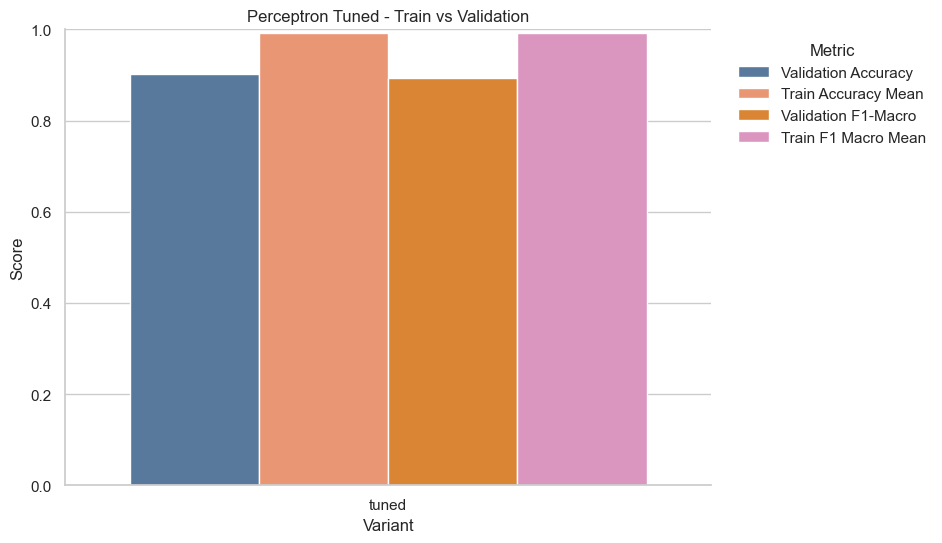

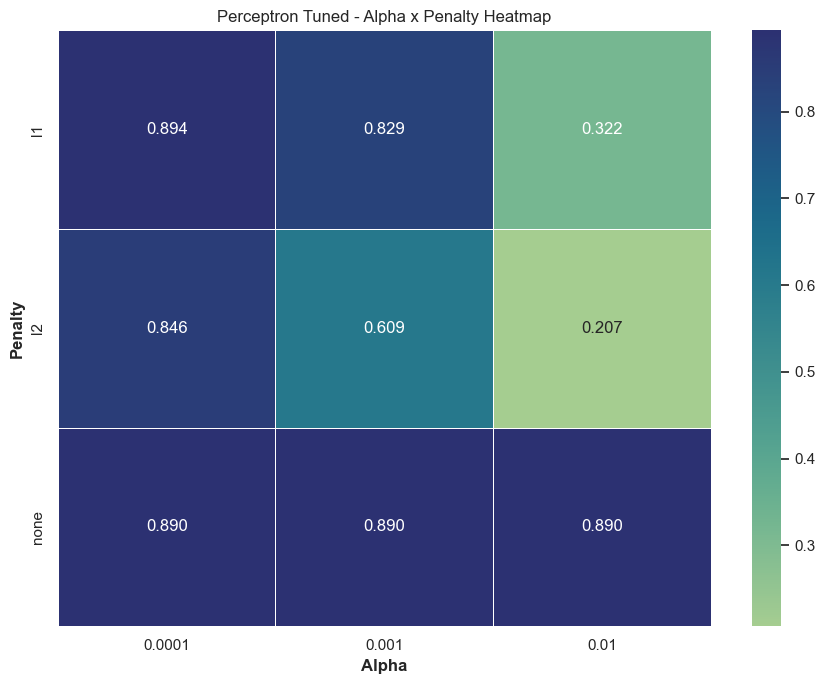

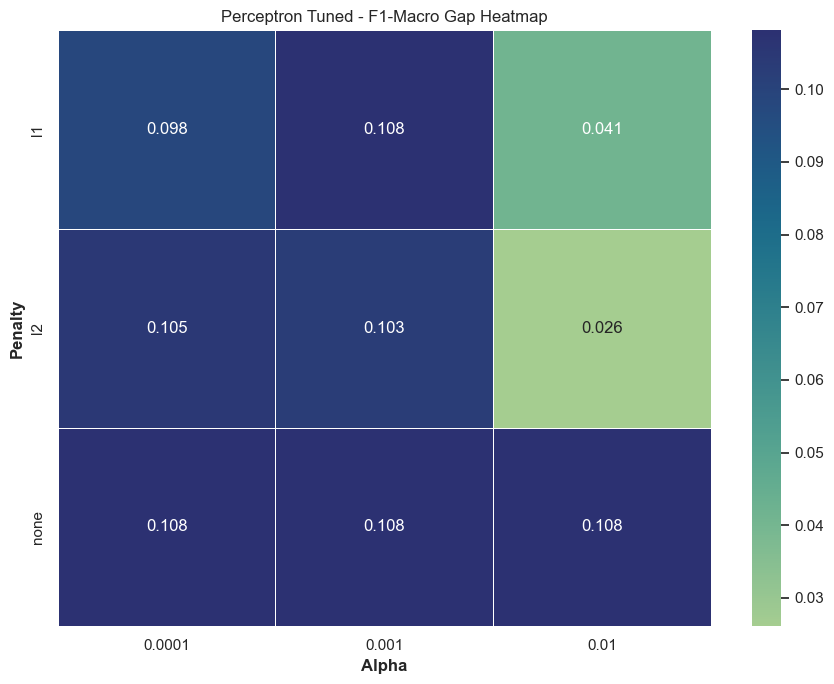

In [26]:
profil_tuned = pd.DataFrame([
    {
        "variante": "tuned",
        **mesures_tuned,
    }
])

tracer_comparaison_variantes(
    profil_tuned,
    colonnes_metriques=["val_accuracy_mean", "train_accuracy_mean", "val_f1_macro_mean", "train_f1_macro_mean"],
    titre="Perceptron Tuned - Train vs Validation",
)
plt.show()

heatmap_tuning = resultats_grid[[
    "param_modele__alpha",
    "param_modele__penalty",
    "mean_test_f1_macro",
]].copy()
heatmap_tuning["param_modele__alpha"] = heatmap_tuning["param_modele__alpha"].astype(str)
heatmap_tuning["param_modele__penalty"] = heatmap_tuning["param_modele__penalty"].where(
    heatmap_tuning["param_modele__penalty"].notna(),
    "none",
).astype(str).replace("nan", "none")

tracer_heatmap_tuning(
    heatmap_tuning,
    x="param_modele__alpha",
    y="param_modele__penalty",
    valeur="mean_test_f1_macro",
    titre="Perceptron Tuned - Alpha x Penalty Heatmap",
)
plt.show()

heatmap_gap_tuning = resultats_grid[[
    "param_modele__alpha",
    "param_modele__penalty",
    "mean_train_f1_macro",
    "mean_test_f1_macro",
]].copy()
heatmap_gap_tuning["generalization_gap_f1_macro"] = heatmap_gap_tuning["mean_train_f1_macro"] - heatmap_gap_tuning["mean_test_f1_macro"]
heatmap_gap_tuning["param_modele__alpha"] = heatmap_gap_tuning["param_modele__alpha"].astype(str)
heatmap_gap_tuning["param_modele__penalty"] = heatmap_gap_tuning["param_modele__penalty"].where(
    heatmap_gap_tuning["param_modele__penalty"].notna(),
    "none",
).astype(str).replace("nan", "none")

tracer_heatmap_tuning(
    heatmap_gap_tuning,
    x="param_modele__alpha",
    y="param_modele__penalty",
    valeur="generalization_gap_f1_macro",
    titre="Perceptron Tuned - F1-Macro Gap Heatmap",
)
plt.show()


### Deductions apres la variante tuned

Le tuning ameliore legerement la variante preprocessed, mais de facon moderee. Le meilleur reglage obtenu est `alpha = 0.0001` avec `penalty = 'l1'`, pour un `F1-macro` moyen d'environ **0.894** et une `accuracy` moyenne d'environ **0.903**. Le gain existe donc bien, mais il reste faible par rapport au saut observe entre la variante default et la variante preprocessed.

La heatmap de performance apporte ici une information importante. Elle montre que la version **sans penalite** reste assez stable quel que soit `alpha`, tandis que l'ajout d'une penalite rend le modele beaucoup plus sensible au choix des hyperparametres. La penalite `l1` n'est benefique que pour une regularisation tres faible (`alpha = 0.0001`), alors que `l2` degrade nettement les performances dans cette grille. La heatmap du **generalization gap** confirme cette lecture : les reglages les moins performants sont aussi ceux qui generalisent le moins bien. On peut donc en deduire que le tuning agit surtout comme un **raffinement local**, et non comme un changement de regime du modele.

Le graphique train vs validation du meilleur modele tuned montre encore un ecart notable entre apprentissage et validation, mais plus faible que pour la variante preprocessed standard. Cela suggere que le tuning reduit legerement l'overfitting sans changer la limite fondamentale du modele. En resume, le preprocessing corrige un probleme structurel confirme par l'EDA, alors que le tuning aide surtout a mieux controler la regularisation et la generalisation autour de la meilleure solution lineaire disponible.


## 4. Synthese finale du notebook

On compare maintenant directement les trois variantes dans le meme espace de lecture.


,variante,val_accuracy_mean,val_f1_macro_mean,elapsed_seconds
0,default,0.811111,0.769950,0.848069
1,preprocessed,0.900000,0.890447,2.240991
2,tuned,0.903030,0.893699,21.187056


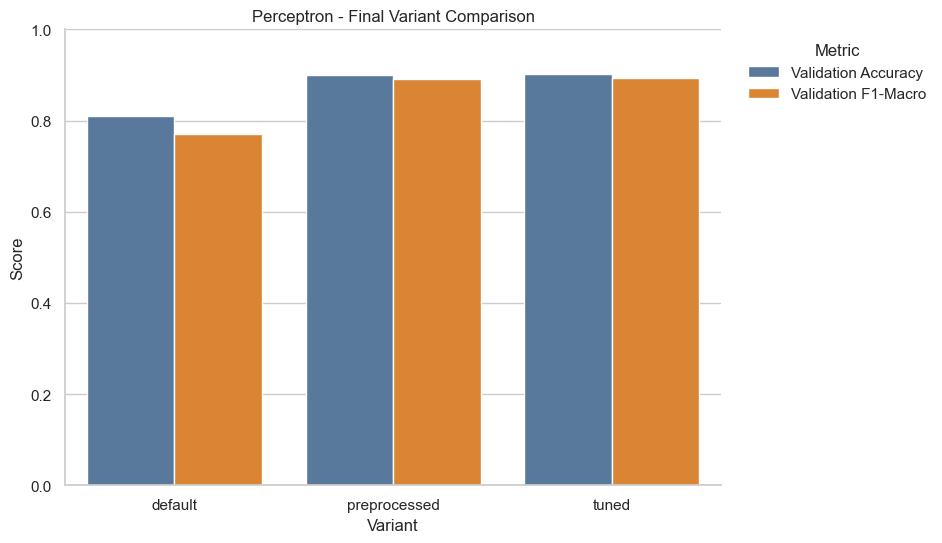

In [27]:
comparaison_finale = pd.DataFrame([
    {"variante": "default", **mesures_default},
    {"variante": "preprocessed", **mesures_preprocessed},
    {"variante": "tuned", **mesures_tuned},
])

display(comparaison_finale[[
    "variante",
    "val_accuracy_mean",
    "val_f1_macro_mean",
    "elapsed_seconds",
]])

tracer_comparaison_variantes(
    comparaison_finale,
    colonnes_metriques=["val_accuracy_mean", "val_f1_macro_mean"],
    titre="Perceptron - Final Variant Comparison",
)
plt.show()


Predictions OOF du meilleur modele sauvegardees dans : C:\Users\moulo\Documents\Projet_Session_IFT712\results\predictions\perceptron__tuned__predictions.csv


,classe_vraie,classe_predite,nombre_erreurs
0,Eucalyptus_Neglecta,Lithocarpus_Cleistocarpus,2
1,Quercus_Kewensis,Quercus_Alnifolia,2
2,Acer_Capillipes,Quercus_Hartwissiana,1
3,Acer_Mono,Liquidambar_Styraciflua,1
4,Acer_Opalus,Quercus_Pyrenaica,1
5,Acer_Opalus,Tilia_Tomentosa,1
6,Acer_Pictum,Alnus_Sieboldiana,1
7,Acer_Rufinerve,Tilia_Tomentosa,1
8,Alnus_Cordata,Quercus_Hartwissiana,1
9,Alnus_Rubra,Acer_Opalus,1


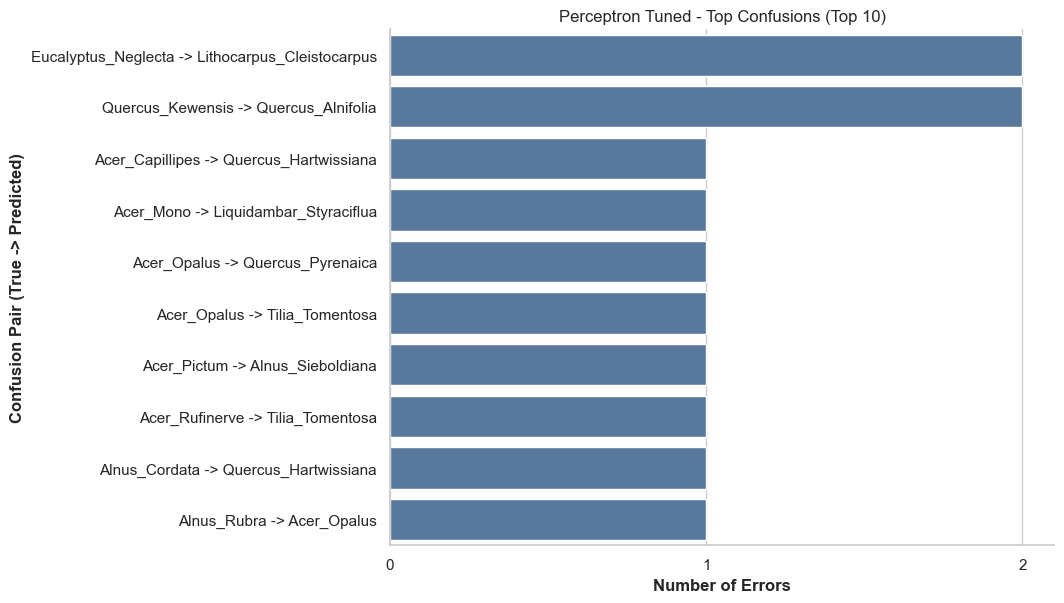

In [28]:
meilleur_modele = grid.best_estimator_
predictions_tuned = predictions_oof(meilleur_modele, X, y, label_encoder=label_encoder)
chemin_predictions_tuned = sauvegarder_predictions(MODEL_NAME, "tuned", predictions_tuned)
confusions_tuned = extraire_top_confusions(
    predictions_tuned["y_true"].to_numpy(),
    predictions_tuned["y_pred"].to_numpy(),
    label_encoder=label_encoder,
    top_n=10,
)

print(f"Predictions OOF du meilleur modele sauvegardees dans : {chemin_predictions_tuned}")
display(confusions_tuned)

tracer_top_confusions(confusions_tuned, titre="Perceptron Tuned - Top Confusions")
plt.show()


## Interpretation scientifique finale

Le Perceptron remplit bien son role de **baseline lineaire** dans ce projet. La version default montre qu'un separateur lineaire brut peut deja capter une partie de la structure du dataset, mais reste trop limite pour bien traiter l'ensemble du probleme. La version preprocessed montre ensuite que le levier principal n'etait pas le tuning, mais bien la **mise a l'echelle des variables**, ce qui valide directement les observations de l'EDA sur les differences d'echelle et la redondance entre descripteurs.

L'ajout des scores train, des `generalization gaps` et des graphes train vs validation permet d'affiner cette lecture. La variante default est surtout limitee par sa simplicite, tandis que les variantes preprocessed et tuned apprennent beaucoup mieux, mais presentent alors un ecart train / validation plus visible. On a donc une transition interessante : on passe d'un modele plutot **contraint** a un modele mieux ajuste mais deja plus sensible a la generalisation. Le tuning reduit un peu cet ecart, sans le supprimer completement.

Le tuning confirme enfin que la meilleure version du Perceptron se situe autour d'une regularisation faible en `l1`, mais le gain observe reste faible par rapport a l'effet du preprocessing. Cela suggere que la limite principale n'est plus un mauvais parametrage, mais la **capacite expressive du modele**. Les erreurs residuelles et les top confusions, meme apres preprocessing et tuning, restent compatibles avec ce que l'EDA suggerait deja : certaines especes occupent des zones proches dans l'espace descripteur et ne peuvent pas etre parfaitement separees par une frontiere strictement lineaire. Le Perceptron constitue donc une baseline solide, interpretable et instructive, mais il est peu probable qu'il soit le meilleur choix final face a des modeles plus expressifs comme le SVM RBF, la foret aleatoire ou le MLP.

D'un point de vue methodologique, il faut aussi noter que l'evaluation tuned repose ici sur une procedure de `GridSearchCV` classique. Pour une estimation finale encore plus rigoureuse, une **nested cross-validation** pourrait etre introduite dans une etape suivante. De la meme facon, une variante `scaled_only` ou une `learning curve` constituerait une extension pertinente pour distinguer encore plus finement l'effet du scaling, de la PCA et de la quantite de donnees d'apprentissage.


## Mini-conclusion

Le Perceptron fournit une baseline lineaire utile sur Leaf Classification. La version default atteint des performances correctes, mais reste nettement en retrait. Le preprocessing apporte le gain decisif, avec un passage d'environ **0.770** a **0.890** en `F1-macro`, ce qui confirme directement les enseignements de l'EDA sur l'importance du scaling. Le tuning ameliore encore legerement le modele, mais son effet reste modeste par rapport au preprocessing. Pour la comparaison globale, on retient donc que le Perceptron est une baseline pertinente et bien interpretable, mais probablement insuffisante pour rivaliser avec les meilleurs modeles non lineaires du projet.
